In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
np.random.seed(100)
print(np.random.rand(3))  

[0.54340494 0.27836939 0.42451759]


In [4]:
customer_id=np.arange(1,101)    

In [5]:
ages=np.random.randint(18,60,100)

In [6]:
income=np.random.randint(20000, 150000, 100)

In [7]:
spending_score=np.random.randint(1,101,100)

In [8]:
orders_per_month=np.random.randint(1,20,100)

In [9]:
gender=np.random.choice(['Male', 'Female', 'Other'], 100)

In [10]:
data={
    'customer_id' : customer_id,
    'age' : ages,
    'income' : income,
    'spending_score' : spending_score,
    'orders_per_month' : orders_per_month,
    'gender' : gender
}

In [11]:
df=pd.DataFrame(data)


In [12]:
df['Total_Spend_Estimate']=df['income']*df['spending_score']/100


In [13]:
df['Category']=np.where(
    df['spending_score']>=70,
    'High',
     np.where(df['spending_score']>=40,
    'Medium',
    'Low'
             )
)


In [14]:
a=df['income'].mean()


In [15]:
b=df['spending_score'].median()


In [16]:
c=df['income'].std()


In [17]:
np.corrcoef(
    df['income'],
    df['spending_score']
)

array([[1.        , 0.08098286],
       [0.08098286, 1.        ]])

In [18]:
df.nlargest(5, 'Total_Spend_Estimate')

,customer_id,age,income,spending_score,orders_per_month,gender,Total_Spend_Estimate,Category
15,16,45,141544,100,4,Female,141544.00,High
44,45,26,145313,93,16,Other,135141.09,High
92,93,57,141655,88,1,Male,124656.40,High
19,20,31,144562,82,17,Female,118540.84,High
54,55,18,140786,83,16,Female,116852.38,High


In [19]:
df.groupby('gender')['income'].mean()

gender
Female    94853.914286
Male      87907.218750
Other     79075.727273
Name: income, dtype: float64

In [20]:
df.groupby('Category')['spending_score'].mean()

Category
High      86.900000
Low       22.205882
Medium    53.638889
Name: spending_score, dtype: float64

In [21]:
df

,customer_id,age,income,spending_score,orders_per_month,gender,Total_Spend_Estimate,Category
0,1,28,20429,54,16,Other,11031.66,Medium
1,2,48,135491,18,18,Other,24388.38,Low
2,3,52,86576,66,11,Other,57140.16,Medium
3,4,20,115756,43,9,Male,49775.08,Medium
4,5,52,93558,94,9,Other,87944.52,High
...,...,...,...,...,...,...,...,...
95,96,20,108755,93,19,Other,101142.15,High
96,97,42,124368,53,13,Other,65915.04,Medium
97,98,35,143634,45,18,Male,64635.30,Medium
98,99,55,83485,14,2,Female,11687.90,Low


([<matplotlib.axis.XTick at 0x1cd788ffd90>,
 [Text(20000, 0, '20000'),
  Text(30000, 0, '30000'),
  Text(40000, 0, '40000'),
  Text(50000, 0, '50000'),
  Text(60000, 0, '60000'),
  Text(70000, 0, '70000'),
  Text(80000, 0, '80000'),
  Text(90000, 0, '90000'),
  Text(100000, 0, '100000'),
  Text(110000, 0, '110000'),
  Text(120000, 0, '120000'),
  Text(130000, 0, '130000'),
  Text(140000, 0, '140000'),
  Text(150000, 0, '150000'),
  Text(160000, 0, '160000')])

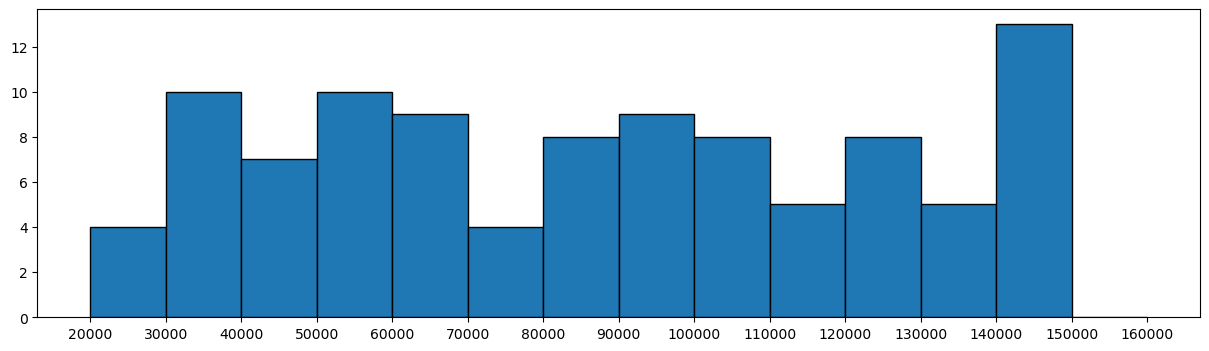

In [40]:
bins=np.arange(20000, 160001, 10000)
plt.figure(figsize=(15,4))
plt.hist(df['income'], edgecolor='black', bins=bins)
plt.xticks(bins)

In [41]:
df.head()

,customer_id,age,income,spending_score,orders_per_month,gender,Total_Spend_Estimate,Category
0,1,28,20429,54,16,Other,11031.66,Medium
1,2,48,135491,18,18,Other,24388.38,Low
2,3,52,86576,66,11,Other,57140.16,Medium
3,4,20,115756,43,9,Male,49775.08,Medium
4,5,52,93558,94,9,Other,87944.52,High


In [46]:
a=df.groupby('Category')['customer_id'].count()
a

Category
High      30
Low       34
Medium    36
Name: customer_id, dtype: int64

([<matplotlib.patches.Wedge at 0x1cd795e8190>,
 [Text(0.6465637011386807, 0.8899187493079641, ''),
  Text(-1.080515977997109, 0.20611943453481438, ''),
  Text(0.46835741088254246, -0.9953096682296427, '')],
 [Text(0.3526711097120076, 0.48541022689525304, '30.0%'),
  Text(-0.5893723516347866, 0.1124287824735351, '34.0%'),
  Text(0.25546767866320497, -0.5428961826707142, '36.0%')])

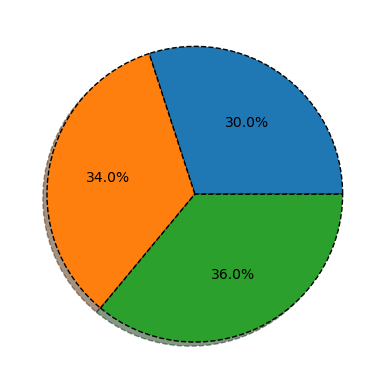

In [56]:
plt.pie(a, 
       autopct='%1.1f%%', 
       wedgeprops={
           'edgecolor' : 'black',
           'linestyle' : '--'
       },
       shadow=True
       )


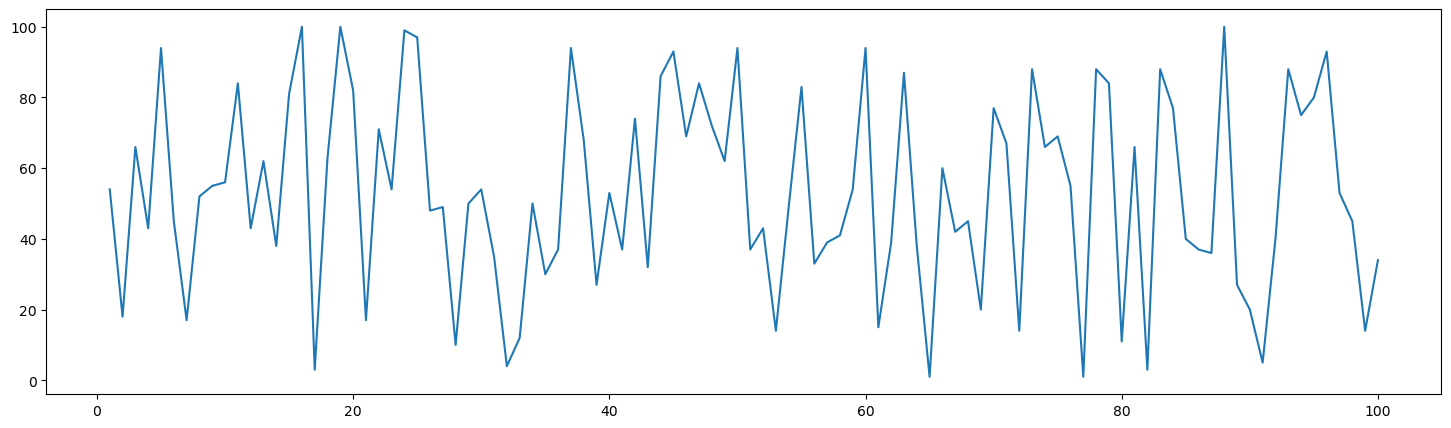

In [63]:
plt.figure(figsize=(18,5))
plt.plot(df['customer_id'], df['spending_score'])

<Axes: xlabel='income', ylabel='spending_score'>

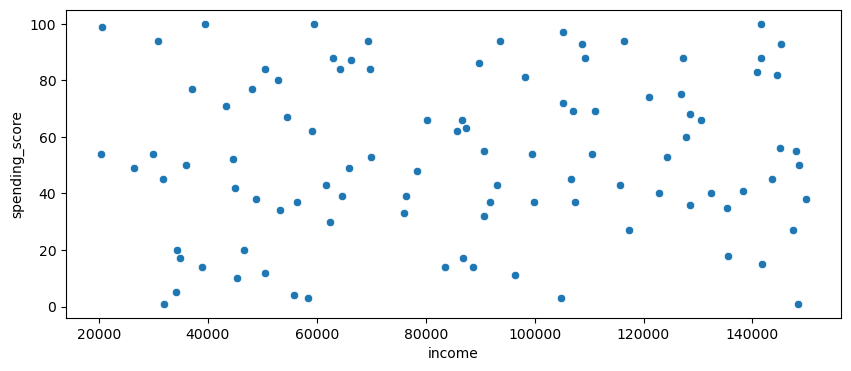

In [66]:
plt.figure(figsize=(10,4))
sns.scatterplot(
    x='income',
    y='spending_score',
    data=df
)